---
## 1. Setup & Imports

In [1]:
import os
import gzip
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# networkx (dont think this ended up getting used but im too scared to remove it)
import networkx as nx
from networkx.algorithms import approximation as approx

# pytorch and pytorch geometric
import torch
import torch.nn as nn
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv
from torch.utils.data import random_split

# pytorch - used in model
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, BatchNorm

# TSPlib
import tsplib95

# sim metrics
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.spatial import Delaunay, cKDTree, QhullError

# or-tools solver
from ortools.constraint_solver import routing_enums_pb2, pywrapcp

from tqdm.notebook import tqdm
from tqdm.notebook import trange

In [63]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Config:
    # seed for reproducibility
    seed: int = 42

    # synthetic graph generation
    n_graphs_to_generate: int = 10000
    n_nodes: int = 50
    n_nodes_var_min: int = 25
    n_nodes_var_max: int = 75
    bounds_A: tuple = (0.0, 0.0)
    bounds_B: tuple = (1.0, 1.0)

    # sparsification
    knn_percent: float = 0.2

    # dataset 
    train_split: float = 0.9

    # model hyperparams
    hidden_dim: int = 64
    n_layers: int = 4

    # training
    batch_size: int = 512
    n_epochs: int = 128
    lr: float = 1e-3
    patience: int = 16
    device: str = field(default_factory=lambda: 'cuda' if torch.cuda.is_available() else 'cpu')

    # saving paths
    dataset_dir: str = 'datasets/'
    weight_dir: str = 'weights/'
    tsplib_dir: str = 'tsplib/tsplib/'

    # testing
    tsplib_max_nodes: list[int] = field(default_factory=lambda: [100, 250, 1000])
    test_dataset_nodes: list[int] = field(default_factory=lambda: [50, 100, 250, 500])
    num_test_graphs: int = 30


#setup
config = Config()
torch.manual_seed(config.seed)
np.random.seed(config.seed)
print(f'Using device: {config.device}')

Using device: cuda


---
## 2. Synthetic Data Generation


In [3]:
#convert numpy coords to a pyg instance
def coords_to_pyg(coords, dist_matrix, tour):
    n = len(coords)
    x = torch.tensor(coords)  

    #only care abt nonzero for edges
    rows, cols = np.nonzero(dist_matrix)
    edge_index = torch.tensor(np.stack([rows, cols], axis=0), dtype=torch.long)  
    edge_attr  = torch.tensor(dist_matrix[rows, cols], dtype=torch.float).unsqueeze(1)  

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, num_nodes=n)

    tour_edges = set()
    for i in range(len(tour)):
        u, v = tour[i], tour[(i + 1) % len(tour)]
        tour_edges.add((u, v))
        tour_edges.add((v, u))
    y = torch.tensor(
        [1.0 if (edge_index[0, i].item(),
                 edge_index[1, i].item()) in tour_edges else 0.0
         for i in range(edge_index.size(1))],
        dtype=torch.float)
    data.y = y
    data.tour = torch.tensor(tour, dtype=torch.long)

    return data

In [4]:
#tsp solver used in this project
#this helper function was made with ai assistance
def solve_tsp_ortools(coords):
    n = len(coords)

    # Compute full pairwise distances internally
    full_dist = squareform(pdist(coords))

    manager = pywrapcp.RoutingIndexManager(n, 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        i = manager.IndexToNode(from_index)
        j = manager.IndexToNode(to_index)
        return int(full_dist[i, j] * 1e6)   # scale to int, no penalty hack needed

    cb_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(cb_index)

    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )

    solution = routing.SolveWithParameters(params)

    tour, index = [], routing.Start(0)
    while not routing.IsEnd(index):
        tour.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    return tour


In [5]:
# graph sparsifier
def sparsify_knn(coords):
    n = len(coords)
    if k is None:
        k = int(config.knn_percent*n)
    k = min(k, n - 1)

    tree = cKDTree(coords)
    distances, indices = tree.query(coords, k=k + 1)

    dist_matrix = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for rank in range(1, k + 1):
            j = indices[i, rank]
            d = distances[i, rank]
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d

    return dist_matrix

#wrapper for either delaunay or knn
#ended up using knn and delaunay is no longer here
def sparsify(coords: np.ndarray) -> np.ndarray:
    return sparsify_knn(coords)

def restore_tour_edges(dist_matrix, tour, coords):
    dist_matrix = dist_matrix.copy()
    n = len(tour)
    for i in range(n):
        u, v = tour[i], tour[(i + 1) % n]
        d = np.linalg.norm(coords[u] - coords[v])
        if d == 0.0:
            d = np.finfo(np.float32).eps   #overlapping nodes, store smallest non-zero float so no div by zero
        dist_matrix[u, v] = d
        dist_matrix[v, u] = d
    return dist_matrix

In [6]:
def generate_random_pyg(n_nodes, A=config.bounds_A, B=config.bounds_B, seed=config.seed):
    """
    Generate_Random_Graph pseudocode:
      for k = 1 to n:
        v_k = (RandU(A_x, B_x), RandU(A_y, B_y))
    """
    rng = np.random.default_rng(seed)
    Ax, Ay = A
    Bx, By = B

    coords = np.column_stack([
        rng.uniform(Ax, Bx, size=n_nodes),
        rng.uniform(Ay, By, size=n_nodes),
    ])

    
    tour        = solve_tsp_ortools(coords)        # fully connected internally
    dist_matrix = sparsify(coords)                 # sparse for the graph
    dist_matrix = restore_tour_edges(dist_matrix, tour, coords)
    data        = coords_to_pyg(coords, dist_matrix, tour)
    data.graph_type = 'random'
    return data


def generate_regular_pyg(n_nodes, A=config.bounds_A, B=config.bounds_B, seed=config.seed):
    """
    Generate_Regular_Graph pseudocode:
      C  = (RandI(20,100), RandI(20,100))
      while |V| < n:
        w  = RandI(4,12),  h  = RandI(1,5)
        D  = (RandI(0,C_x), RandI(0,C_y))
        S  = (RandI(-1,1),  RandI(-1,1))
        for i = 1 to w:
          for j = 1 to h:
            v_k = (A_x + (B_x-A_x)/C_x * (D_x + i*S_x - j*S_y),
                   A_y + (B_y-A_y)/C_y * (D_y + i*S_y + j*S_x))
            V = V + {v_k}
            if |V| >= n then return V
    """
    rng = np.random.default_rng(seed)
    Ax, Ay = A
    Bx, By = B

    Cx = int(rng.integers(20, 101))   # RandI(20,100), inclusive
    Cy = int(rng.integers(20, 101))

    V = []
    while len(V) < n_nodes:
        w  = int(rng.integers(4,  13))   # RandI(4,12)
        h  = int(rng.integers(1,   6))   # RandI(1,5)
        Dx = int(rng.integers(0, Cx + 1))
        Dy = int(rng.integers(0, Cy + 1))
        Sx = int(rng.integers(-1,  2))   # RandI(-1,1)
        Sy = int(rng.integers(-1,  2))

        for i in range(1, w + 1):
            for j in range(1, h + 1):
                vx = Ax + (Bx - Ax) / Cx * (Dx + i * Sx - j * Sy)
                vy = Ay + (By - Ay) / Cy * (Dy + i * Sy + j * Sx)
                V.append((vx, vy))
                if len(V) >= n_nodes:
                    coords = np.array(V)
                    
                    tour        = solve_tsp_ortools(coords)        # fully connected internally
                    dist_matrix = sparsify(coords)                 # sparse for the graph
                    dist_matrix = restore_tour_edges(dist_matrix, tour, coords)
                    data        = coords_to_pyg(coords, dist_matrix, tour)
                    data.graph_type = 'regular'
                    return data

    coords = np.array(V)
    
    tour        = solve_tsp_ortools(coords)        # fully connected internally
    dist_matrix = sparsify(coords)                 # sparse for the graph
    dist_matrix = restore_tour_edges(dist_matrix, tour, coords)
    data        = coords_to_pyg(coords, dist_matrix, tour)
    data.graph_type = 'regular'
    return data


def generate_cluster_pyg(n_nodes, A=config.bounds_A, B=config.bounds_B, seed=config.seed):
    """
    Generate_Cluster_Graph pseudocode:
      while |V| < n:
        c   = RandI(4,12)
        μ_x = RandU(A_x + 0.2*(B_x-A_x), B_x - 0.2*(B_x-A_x))
        μ_y = RandU(A_y + 0.2*(B_y-A_y), B_y - 0.2*(B_y-A_y))
        σ_x = RandU(0.005*(B_x-A_x), 0.05*(B_x-A_x))
        σ_y = RandU(0.005*(B_y-A_y), 0.05*(B_y-A_y))
        for i = 1 to c:
          v_k = (RandN(μ_x, σ_x), RandN(μ_y, σ_y))
          V = V + {v_k}
          if |V| >= n then return V
    """
    rng = np.random.default_rng(seed)
    Ax, Ay = A
    Bx, By = B

    V = []
    while len(V) < n_nodes:
        c = int(rng.integers(4, 13))   # RandI(4,12)

        mu_x    = rng.uniform(Ax + 0.2 * (Bx - Ax),  Bx - 0.2 * (Bx - Ax))
        mu_y    = rng.uniform(Ay + 0.2 * (By - Ay),  By - 0.2 * (By - Ay))
        sigma_x = rng.uniform(0.005 * (Bx - Ax),     0.05  * (Bx - Ax))
        sigma_y = rng.uniform(0.005 * (By - Ay),     0.05  * (By - Ay))

        for _ in range(c):
            vx = rng.normal(mu_x, sigma_x)
            vy = rng.normal(mu_y, sigma_y)
            V.append((vx, vy))
            if len(V) >= n_nodes:
                coords = np.array(V)
                
                tour        = solve_tsp_ortools(coords)        # fully connected internally
                dist_matrix = sparsify(coords)                 # sparse for the graph
                dist_matrix = restore_tour_edges(dist_matrix, tour, coords)
                data        = coords_to_pyg(coords, dist_matrix, tour)
                data.graph_type = 'cluster'
                return data

    coords = np.array(V)
    
    tour        = solve_tsp_ortools(coords)        # fully connected internally
    dist_matrix = sparsify(coords)                 # sparse for the graph
    dist_matrix = restore_tour_edges(dist_matrix, tour, coords)
    data        = coords_to_pyg(coords, dist_matrix, tour)
    data.graph_type = 'cluster'
    return data

### Visualization of each Graph Type

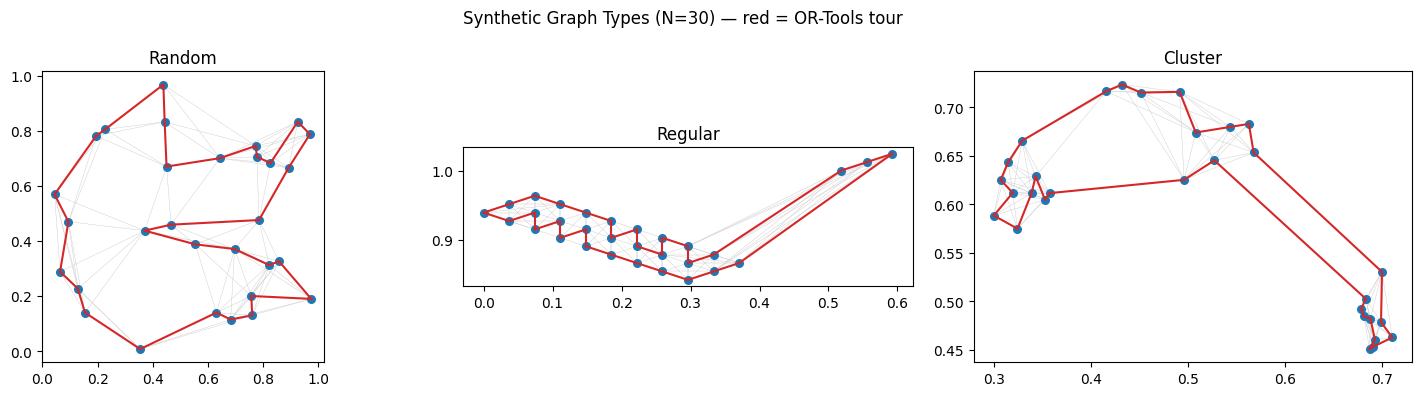

In [7]:
#visualizing instances
#done with ai assistance
samples = {
    'Random':  generate_random_pyg(30),
    'Regular': generate_regular_pyg(30),
    'Cluster': generate_cluster_pyg(30),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, samples.items()):
    coords = data.x.numpy()
    tour   = data.tour.tolist()

    # Draw all sparse edges
    for i in range(data.edge_index.size(1)):
        u, v = data.edge_index[0, i].item(), data.edge_index[1, i].item()
        ax.plot([coords[u, 0], coords[v, 0]],
                [coords[u, 1], coords[v, 1]],
                c='lightgray', lw=0.2, zorder=0)

    ax.scatter(coords[:, 0], coords[:, 1], s=30, zorder=1)

    for i in range(len(tour)):
        u, v = tour[i], tour[(i + 1) % len(tour)]
        ax.plot([coords[u, 0], coords[v, 0]],
                [coords[u, 1], coords[v, 1]],
                c='tab:red', lw=1.5, zorder=2)

    ax.set_title(name)
    ax.set_aspect('equal')

plt.suptitle(f'Synthetic Graph Types (N={30}) — red = OR-Tools tour')
plt.tight_layout()
plt.show()

In [8]:
#used for checking tour exists while refining graph generation
def sanity_check_tour_edges(data) -> bool:
    tour    = data.tour.tolist()
    edge_set = set(
        (data.edge_index[0, i].item(), data.edge_index[1, i].item())
        for i in range(data.edge_index.size(1))
    )

    missing = []
    for i in range(len(tour)):
        u, v = tour[i], tour[(i + 1) % len(tour)]
        if (u, v) not in edge_set:
            missing.append((u, v))

    if missing:
        print(f"FAIL — {len(missing)} missing tour edge(s): {missing}")
        return False

    print(f"OK — all {len(tour)} tour edges present in edge_index")
    return True
for name, data in samples.items():
    print(f"{name}: ", end="")
    sanity_check_tour_edges(data)

Random: OK — all 30 tour edges present in edge_index
Regular: OK — all 30 tour edges present in edge_index
Cluster: OK — all 30 tour edges present in edge_index


---
## 3. GNN Architecture

In [9]:
#GNN Encoder with n layers, uses GINEConv for convolutions
class GNNEncoder(nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, hidden_dim=128, n_layers=4):
        super().__init__()
        self.node_proj = nn.Linear(node_dim, hidden_dim)
        self.edge_proj = nn.Linear(edge_dim, hidden_dim)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Linear(hidden_dim * 2, hidden_dim),
            )
            self.convs.append(GINEConv(mlp, edge_dim=hidden_dim)) 
            self.norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, data: Data) -> torch.Tensor:
        x = self.node_proj(data.x)
        edge_attr = self.edge_proj(data.edge_attr)
        for conv, norm in zip(self.convs, self.norms):
            x = F.relu(norm(conv(x, data.edge_index, edge_attr)))
        return x  # [total_N, H]


#Autoregressive decoder
#vectorized with ai assistance, our original implementation could only do batches of size 1, making training very slow
class ARDecoder(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.W_cur = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_ctx = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_j   = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v     = nn.Linear(hidden_dim, 1,          bias=False)
        self.gru   = nn.GRUCell(hidden_dim, hidden_dim)

    # vectorizing helpers

    def _prepare_batch(
        self,
        h:          torch.Tensor,   # [total_N, H]
        edge_index: torch.Tensor,   # [2, total_E]
        batch:      torch.Tensor,   # [total_N]
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        device  = h.device
        B       = int(batch.max().item()) + 1
        H       = h.size(1)
        counts  = torch.bincount(batch, minlength=B)                   # [B]
        offsets = torch.zeros(B, dtype=torch.long, device=device)
        offsets[1:] = counts[:-1].cumsum(0)
        N_max   = int(counts.max().item())

        # ── padded node embeddings ────────────────────────────────────────────
        h_3d     = torch.zeros(B, N_max, H, device=device)
        pad_mask = torch.ones(B, N_max, dtype=torch.bool, device=device)  # True = invalid

        node_ids  = torch.arange(h.size(0), device=device)
        local_ids = node_ids - offsets[batch]          # position within each graph
        h_3d[batch, local_ids]     = h
        pad_mask[batch, local_ids] = False

        # ── adjacency [B, N_max, N_max] ───────────────────────────────────────
        src, dst  = edge_index
        g_ids     = batch[src]
        local_src = src - offsets[g_ids]
        local_dst = dst - offsets[g_ids]
        adj = torch.zeros(B, N_max, N_max, dtype=torch.bool, device=device)
        adj[g_ids, local_src, local_dst] = True

        return h_3d, adj, pad_mask, counts, offsets

    def _flat_to_padded(
        self,
        flat:    torch.Tensor,   # [total_N] long
        batch:   torch.Tensor,   # [total_N]
        offsets: torch.Tensor,   # [B]
        N_max:   int,
        pad_val: int = 0,
    ) -> torch.Tensor:           # [B, N_max] long
        B      = offsets.size(0)
        device = flat.device
        out    = torch.full((B, N_max), pad_val, dtype=flat.dtype, device=device)
        ids    = torch.arange(flat.size(0), device=device)
        local  = ids - offsets[batch]
        out[batch, local] = flat
        return out

    def _score_and_mask(self, h_3d, current, context, visited, adj, pad_mask):
        idx   = torch.arange(h_3d.size(0), device=h_3d.device)
        h_cur = h_3d[idx, current]
    
        scores = self.v(torch.tanh(
            self.W_cur(h_cur).unsqueeze(1) +
            self.W_ctx(context).unsqueeze(1) +
            self.W_j(h_3d)
        )).squeeze(-1)
    
        invalid = visited | pad_mask
        scores  = scores.masked_fill(invalid, float('-inf'))
    
        cur_adj       = adj[idx, current]
        reachable     = cur_adj & ~invalid
        has_reachable = reachable.any(dim=1, keepdim=True)
        non_neighbour = ~cur_adj & ~invalid
        scores = scores.masked_fill(has_reachable & non_neighbour, float('-inf'))
    
        log_p = F.log_softmax(scores, dim=1)
        # rows where every score was -inf (finished graphs) → NaN; replace with 0
        log_p = log_p.nan_to_num(nan=0.0)
        return log_p

    # teacher forced training

    def forward_teacher_forced(
        self,
        h:          torch.Tensor,   # [total_N, H]
        edge_index: torch.Tensor,   # [2, total_E]
        batch:      torch.Tensor,   # [total_N]
        tours_flat: torch.Tensor,   # [total_N] long – concatenated GT tours
    ) -> tuple[torch.Tensor, torch.Tensor]:
        device = h.device
        B      = int(batch.max().item()) + 1
        idx    = torch.arange(B, device=device)

        h_3d, adj, pad_mask, counts, offsets = self._prepare_batch(h, edge_index, batch)
        N_max = h_3d.size(1)

        tours   = self._flat_to_padded(tours_flat, batch, offsets, N_max)  # [B, N_max]
        visited = torch.zeros(B, N_max, dtype=torch.bool, device=device)
        visited[idx, tours[:, 0]] = True
        context = h_3d[idx, tours[:, 0]]    # [B, H]

        log_probs_steps = []
        valid_steps     = []

        for step in range(N_max - 1):
            valid     = step < (counts - 1)          # [B] bool – is this step real?
            current   = tours[:, step]               # [B]
            next_node = tours[:, step + 1]           # [B]

            log_p = self._score_and_mask(h_3d, current, context, visited, adj, pad_mask)
            log_probs_steps.append(log_p[idx, next_node])   # [B]
            valid_steps.append(valid)

            # Update state only for graphs that still have steps
            visited[idx[valid], next_node[valid]] = True
            new_ctx = self.gru(h_3d[idx, next_node], context)          # [B, H]
            context = torch.where(valid.unsqueeze(1), new_ctx, context) # freeze done graphs

        log_probs  = torch.stack(log_probs_steps, dim=1)  # [B, N_max-1]
        valid_mask = torch.stack(valid_steps,     dim=1)  # [B, N_max-1]
        return log_probs, valid_mask

    # greedy for eval

    def forward(
        self,
        h:          torch.Tensor,
        edge_index: torch.Tensor,
        batch:      torch.Tensor,
        start_node: int = 0,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        device = h.device
        B      = int(batch.max().item()) + 1
        idx    = torch.arange(B, device=device)

        h_3d, adj, pad_mask, counts, offsets = self._prepare_batch(h, edge_index, batch)
        N_max = h_3d.size(1)

        visited = torch.zeros(B, N_max, dtype=torch.bool, device=device)
        current = torch.full((B,), start_node, dtype=torch.long, device=device)
        visited[idx, current] = True
        context = h_3d[idx, current]

        tours_steps = [current]
        log_probs   = []

        for _ in range(N_max - 1):
            log_p     = self._score_and_mask(h_3d, current, context, visited, adj, pad_mask)
            next_node = log_p.argmax(dim=1)           # [B]

            log_probs.append(log_p[idx, next_node])
            visited[idx, next_node] = True
            tours_steps.append(next_node)
            new_ctx = self.gru(h_3d[idx, next_node], context)
            context = new_ctx
            current = next_node

        return (
            torch.stack(tours_steps, dim=1),   # [B, N_max]
            torch.stack(log_probs,   dim=1),   # [B, N_max-1]
            counts,                            # [B]
        )


# fuull model

class TSPGNNModel(nn.Module):
    def __init__(self, node_dim=2, edge_dim=1, hidden_dim=128, n_layers=4):
        super().__init__()
        self.encoder = GNNEncoder(node_dim, edge_dim, hidden_dim, n_layers)
        self.decoder = ARDecoder(hidden_dim)

    def forward(self, data: Data):
        h = self.encoder(data)
        return self.decoder(h, data.edge_index, data.batch)

    def forward_teacher_forced(self, data: Data, tours_flat: torch.Tensor):
        h = self.encoder(data)
        return self.decoder.forward_teacher_forced(h, data.edge_index, data.batch, tours_flat)

---
## 4. Dataset Generation

In [10]:
#generate 10000 graphs for each dataset

class TSPDataset(InMemoryDataset):
    def __init__(self, data_list: list[Data]):
        super().__init__(root=None, transform=None)
        self.data, self.slices = self.collate(data_list)


GRAPH_GENERATORS = {
    'random':  generate_random_pyg,
    'regular': generate_regular_pyg,
    'cluster': generate_cluster_pyg,
}

def build_dataset(graph_types, n_graphs, fixed_nodes=None,
                  node_min=None, node_max=None, base_seed=config.seed):
    rng        = np.random.default_rng(base_seed)
    data_list  = []
    seed       = base_seed

    for i in tqdm(range(n_graphs), desc=f"{'+'.join(graph_types)}"):
        graph_type = graph_types[i % len(graph_types)]
        n_nodes    = fixed_nodes if fixed_nodes is not None \
                     else int(rng.integers(node_min, node_max + 1))
        data  = GRAPH_GENERATORS[graph_type](n_nodes, seed=base_seed+i)  

        data_list.append(data)

    return TSPDataset(data_list)

def generate_all_datasets(save_dir='datasets', n_graphs=config.n_graphs_to_generate, seed=config.seed):
    os.makedirs(save_dir, exist_ok=True)

    configs = [
        ('random_n.pt',  ['random'],                       config.n_nodes,   None, None),
        ('regular_n.pt', ['regular'],                      config.n_nodes,   None, None),
        ('cluster_n.pt', ['cluster'],                      config.n_nodes,   None, None),
        ('mixed_n.pt',   ['random', 'regular', 'cluster'], config.n_nodes,   None, None),
        ('random_var.pt',  ['random'],                       None, config.n_nodes_var_min,   config.n_nodes_var_max  ),
        ('regular_var.pt', ['regular'],                      None, config.n_nodes_var_min,   config.n_nodes_var_max  ),
        ('cluster_var.pt', ['cluster'],                      None, config.n_nodes_var_min,   config.n_nodes_var_max  ),
        ('mixed_var.pt',   ['random', 'regular', 'cluster'], None, config.n_nodes_var_min,   config.n_nodes_var_max  ),
    ]

    for idx, (filename, graph_types, fixed, lo, hi) in enumerate(configs):
        path = os.path.join(save_dir, filename)
        if os.path.exists(path):
            print(f'Skipping {filename} (already exists)')
            continue

        dataset = build_dataset(graph_types, n_graphs, fixed, lo, hi,
                                base_seed=seed + idx * n_graphs)
        torch.save(dataset, path)


generate_all_datasets()

random:   0%|          | 0/10000 [00:00<?, ?it/s]

regular:   0%|          | 0/10000 [00:00<?, ?it/s]

cluster:   0%|          | 0/10000 [00:00<?, ?it/s]

random+regular+cluster:   0%|          | 0/10000 [00:00<?, ?it/s]

random:   0%|          | 0/10000 [00:00<?, ?it/s]

regular:   0%|          | 0/10000 [00:00<?, ?it/s]

cluster:   0%|          | 0/10000 [00:00<?, ?it/s]

random+regular+cluster:   0%|          | 0/10000 [00:00<?, ?it/s]

---
## 5. Training

### 5.1 metrics

In [11]:
#metrics vectorized with ai assistance to handle larger batches than size 1
def tour_length_batched(coords_flat: torch.Tensor,
                        tours:       torch.Tensor,
                        counts:      torch.Tensor,
                        batch:       torch.Tensor) -> list[float]:

    device  = coords_flat.device
    B       = tours.size(0)
    N_max   = tours.size(1)
    offsets = torch.zeros(B, dtype=torch.long, device=device)
    offsets[1:] = torch.bincount(batch)[:-1].cumsum(0)

    # Convert local tour indices → global flat indices
    global_tours = tours + offsets.unsqueeze(1)          # [B, N_max]

    # Gather coordinates for each step
    coords_3d = coords_flat[global_tours]                 # [B, N_max, 2]

    # Next-step indices with wraparound (only within real nodes)
    counts_col = counts.unsqueeze(1)                      # [B, 1]
    steps      = torch.arange(N_max, device=device).unsqueeze(0)  # [1, N_max]
    next_steps = (steps + 1) % counts_col                # [B, N_max]  wraps per graph

    # Gather next-step coords
    next_steps_exp = next_steps.unsqueeze(-1).expand_as(coords_3d)
    next_coords    = torch.gather(coords_3d, 1, next_steps_exp)   # [B, N_max, 2]

    # Edge lengths
    edge_lens = torch.norm(coords_3d - next_coords, dim=2)        # [B, N_max]

    # Zero out padded steps
    valid_mask = steps < counts_col                               # [B, N_max]
    edge_lens  = edge_lens * valid_mask.float()

    return edge_lens.sum(dim=1).tolist()                          # [B]


def pct_within_optimal(model, loader, device) -> float:
    model.eval()
    gaps = []
    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)
            counts = torch.bincount(batch.batch)   # ground truth for both

            # model forward
            h = model.encoder(batch)
            tour_tensor, _, _ = model.decoder(h, batch.edge_index, batch.batch)

            # pad optimal tours using the same counts
            opt_tours_padded = _flat_to_padded_tours(batch.tour, batch.batch, counts, device)

            opt_lens   = tour_length_batched(batch.x, opt_tours_padded, counts, batch.batch)
            model_lens = tour_length_batched(batch.x, tour_tensor,      counts, batch.batch)

            for ml, ol in zip(model_lens, opt_lens):
                if ol > 0:   # guard against degenerate graphs
                    gaps.append((ml / ol - 1.0) * 100.0)

    return float(np.mean(gaps)) if gaps else 0.0


def _flat_to_padded_tours(
    tours_flat: torch.Tensor,   # [total_N]
    batch:      torch.Tensor,   # [total_N]
    counts:     torch.Tensor,   # [B]
    device,
) -> torch.Tensor:              # [B, N_max]
    B     = counts.size(0)
    N_max = int(counts.max().item())
    offsets = torch.zeros(B, dtype=torch.long, device=device)
    offsets[1:] = counts[:-1].cumsum(0)
    out   = torch.zeros(B, N_max, dtype=torch.long, device=device)
    ids   = torch.arange(tours_flat.size(0), device=device)
    local = ids - offsets[batch]
    out[batch, local] = tours_flat
    return out

### 5.2 Training loop function

In [19]:
#training loop
def train(model, train_loader, val_loader,
          n_epochs=config.n_epochs, lr=config.lr,
          patience=config.patience, device=config.device):

    model = model.to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_pct_optimal': []}

    best_val_loss = float('inf')
    best_weights = None
    epochs_no_impr = 0
    epoch_bar = tqdm(range(1, n_epochs + 1), desc='Training', unit='epoch')

    for epoch in epoch_bar:
        # train
        model.train()
        train_losses = []  

        for data in tqdm(train_loader, desc=f'  Epoch {epoch} train', leave=False):
            data = data.to(device)

            optimiser.zero_grad()
            log_probs, valid_mask = model.forward_teacher_forced(data, data.tour)
            loss = -log_probs[valid_mask].mean()
            loss.backward()
            optimiser.step()
            train_losses.append(loss.item())

        # val
        model.eval()
        val_losses = []  
        
        with torch.no_grad():
            for data in tqdm(val_loader, desc=f'  Epoch {epoch} val  ', leave=False):
                data = data.to(device)
                log_probs, valid_mask = model.forward_teacher_forced(data, data.tour)
                loss = -log_probs[valid_mask].mean()
                val_losses.append(loss.item())

        mean_train = float(np.mean(train_losses))
        mean_val = float(np.mean(val_losses))
        val_pct = pct_within_optimal(model, val_loader, device)

        history['train_loss'].append(mean_train)
        history['val_loss'].append(mean_val)
        history['val_pct_optimal'].append(val_pct)
        epoch_bar.set_postfix(train=f'{mean_train:.4f}', val=f'{mean_val:.4f}', gap=f'{val_pct:.2f}%')

        # early stopping
        if mean_val < best_val_loss:
            best_val_loss = mean_val
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_impr = 0
        else:
            epochs_no_impr += 1
            if epochs_no_impr >= patience:
                epoch_bar.write(f'Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_weights)
    return model, history

### 5.3 Training

In [ ]:
#run the training loop for each dataset
dataset_paths = ['random_n.pt','regular_n.pt','cluster_n.pt','mixed_n.pt','random_var.pt','regular_var.pt','cluster_var.pt','mixed_var.pt']
all_histories = {}

for path in dataset_paths:
    print(f'\n=== Training on {path} ===')
    
    path = config.dataset_dir+path
    dataset = torch.load(path, weights_only=False)
    #dataset = dataset[:len(dataset) // 10]
    n_train = int(len(dataset) * config.train_split)
    n_val = len(dataset) - n_train
    train_ds, val_ds = random_split(dataset, [n_train, n_val])

    train_loader = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds,   batch_size=config.batch_size, shuffle=False)

    model = TSPGNNModel(node_dim=2, edge_dim=1, hidden_dim=config.hidden_dim, n_layers=config.n_layers)
    model, history = train(model, train_loader, val_loader)

    weights_path = path.replace(config.dataset_dir, config.weight_dir).replace('.pt', '_weights.pt')
    os.makedirs(os.path.dirname(weights_path), exist_ok=True)
    torch.save(model.state_dict(), weights_path)
    print(f'Saved weights → {weights_path}')
    
    label = path.replace('.pt', '')
    all_histories[label] = history

Saved plot → plots/val_loss_split.png
Saved plot → plots/val_pct_split.png


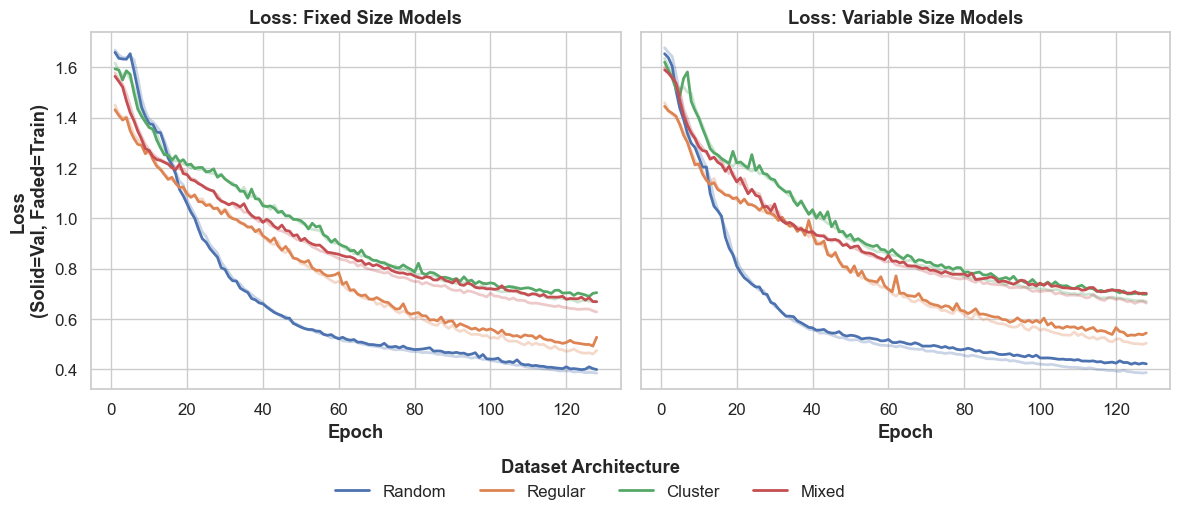

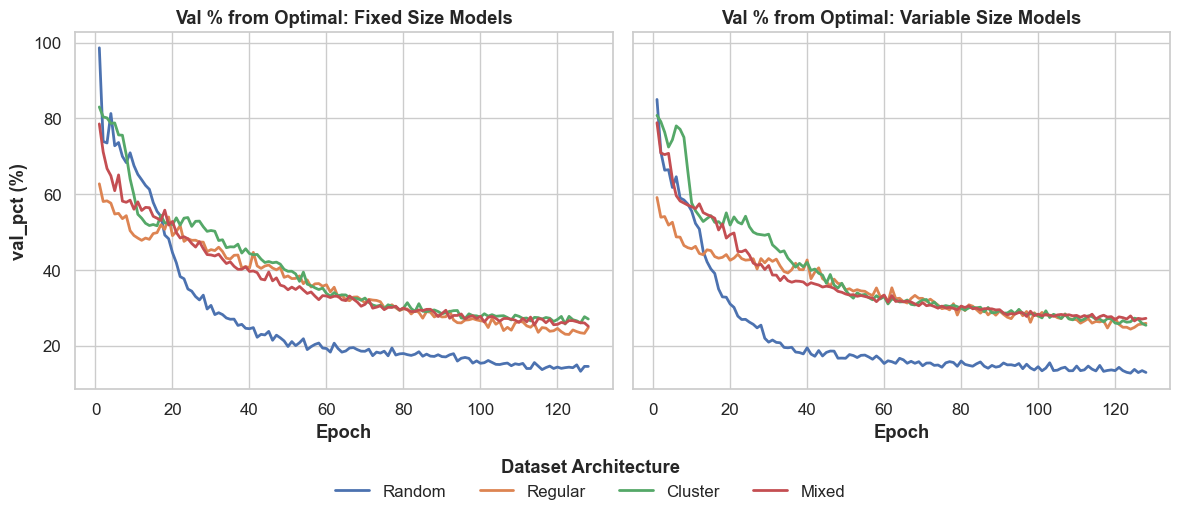

In [82]:
#plot training data
#made with ai assistance

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
colors = sns.color_palette("deep", 4)
dataset_types = ['random', 'regular', 'cluster', 'mixed']
fig_loss, axes_loss = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig_pct, axes_pct = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

lines_for_legend = []
labels_for_legend = []

for label, history in all_histories.items():
    epochs = range(1, len(history['val_loss']) + 1)
    clean_label = label.replace('datasets/', '')
    
    base_name = clean_label.split('_')[0]
    color_idx = dataset_types.index(base_name)
    color = colors[color_idx]
    
    if clean_label.endswith('_n'):
        col = 0  # Left column
    else:
        col = 1  # Right column
        
    train_loss = history.get('train_loss', history.get('loss'))
    if train_loss is not None:
        axes_loss[col].plot(epochs, train_loss, linewidth=2.0, color=color, alpha=0.3)
    
    # Plot Validation Loss (Solid) on the Loss figure
    l, = axes_loss[col].plot(epochs, history['val_loss'], linewidth=2.0, color=color)
    
    # Plot on the Percentage figure
    axes_pct[col].plot(epochs, history['val_pct_optimal'], linewidth=2.0, color=color)
    
    # Grab legend info only once (from the left column)
    if clean_label.endswith('_n'):
        lines_for_legend.append(l)
        labels_for_legend.append(base_name.capitalize())

axes_loss[0].set_title('Loss: Fixed Size Models', fontweight='bold')
axes_loss[1].set_title('Loss: Variable Size Models', fontweight='bold')

# Added a note about the transparent lines to the Y-axis label
axes_loss[0].set_ylabel('Loss\n(Solid=Val, Faded=Train)', fontweight='bold')

for ax in axes_loss:
    ax.set_xlabel('Epoch', fontweight='bold')

fig_loss.legend(lines_for_legend, labels_for_legend, loc='lower center', 
                bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, 
                title="Dataset Architecture", title_fontproperties={'weight':'bold'})

fig_loss.tight_layout()
fig_loss.subplots_adjust(bottom=0.2) # Leave space for the legend

axes_pct[0].set_title('Val % from Optimal: Fixed Size Models', fontweight='bold')
axes_pct[1].set_title('Val % from Optimal: Variable Size Models', fontweight='bold')
axes_pct[0].set_ylabel('val_pct (%)', fontweight='bold')

for ax in axes_pct:
    ax.set_xlabel('Epoch', fontweight='bold')

fig_pct.legend(lines_for_legend, labels_for_legend, loc='lower center', 
               bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=False, 
               title="Dataset Architecture", title_fontproperties={'weight':'bold'})

fig_pct.tight_layout()
fig_pct.subplots_adjust(bottom=0.2) # Leave space for the legend

os.makedirs('plots', exist_ok=True)

# Save Loss Plot
fig_loss.savefig('plots/val_loss_split.png', dpi=150, bbox_inches='tight')
print('Saved plot → plots/val_loss_split.png')

# Save Percentage Plot
fig_pct.savefig('plots/val_pct_split.png', dpi=150, bbox_inches='tight')
print('Saved plot → plots/val_pct_split.png')

plt.show()

---
## 6. Generalization to TSPlib Instances

In [26]:
#similar to converting synthetic graphs to pyg
#but for tsp

def load_tsplib_as_pyg(path, max_nodes = 50):
    problem = tsplib95.load(path)
    if problem.edge_weight_type not in ('EUC_2D', 'ATT', 'GEO') or not problem.node_coords:
        return None

    nodes = list(problem.get_nodes())
    if len(nodes) > max_nodes:
        return None

    coords_raw = np.array([problem.node_coords[n] for n in nodes], dtype=float)
    coords = (coords_raw - coords_raw.min(0)) / (coords_raw.max(0) - coords_raw.min(0) + 1e-8)

    dist_matrix = np.linalg.norm(coords[:, None] - coords[None, :], axis=-1)  # [N, N]
    np.fill_diagonal(dist_matrix, 0.0)

    tour = solve_tsp_ortools(coords)
    if tour is None:
        print(f'Solver failed: {os.path.basename(path)} (N={len(nodes)}) — skipping')
        return None

    data = coords_to_pyg(coords, dist_matrix, tour)
    data.name = os.path.basename(path).replace('.tsp', '')
    return data


def build_tsplib_dataset(tsplib_dir = config.tsplib_dir, max_nodes = 50):
    tsp_files = [f for f in os.listdir(tsplib_dir) if f.endswith('.tsp')]
    data_list, skipped = [], []

    for f in tqdm(tsp_files, desc='TSPlib'):
        data = load_tsplib_as_pyg(os.path.join(tsplib_dir, f), max_nodes=max_nodes)
        if data is not None:
            data_list.append(data)
        else:
            skipped.append(f)

    print(f'Loaded:  {len(data_list)} instances')
    print(f'Skipped: {len(skipped)} instances — {skipped}')
    return TSPDataset(data_list)


def generate_tsplib_dataset(max_nodes, prefix, save_dir = config.dataset_dir):
    os.makedirs(save_dir, exist_ok=True)
    filename = f'{prefix}tsplib.pt'
    path = os.path.join(save_dir, filename)

    if os.path.exists(path):
        print(f'Skipping {filename} (already exists)')
        return

    dataset = build_tsplib_dataset(max_nodes=max_nodes)
    torch.save(dataset, path)
    print(f'Saved {len(dataset)} TSPlib instances -> {path}')


def load_tsplib_dataset(prefix = '', save_dir = config.dataset_dir:
    filename = f'{prefix}tsplib.pt'
    path = os.path.join(save_dir, filename)
    dataset = torch.load(path)
    print(f'Loaded {len(dataset)} TSPlib instances <- {path}')
    return dataset


for n in config.tsplib_max_nodes:
    generate_tsplib_dataset(n, f'n{n}_')

TSPlib:   0%|          | 0/111 [00:00<?, ?it/s]

Loaded:  17 instances
Skipped: 94 instances — ['a280.tsp', 'ali535.tsp', 'att532.tsp', 'bayg29.tsp', 'bays29.tsp', 'bier127.tsp', 'brazil58.tsp', 'brd14051.tsp', 'brg180.tsp', 'ch130.tsp', 'ch150.tsp', 'd1291.tsp', 'd15112.tsp', 'd1655.tsp', 'd18512.tsp', 'd198.tsp', 'd2103.tsp', 'd493.tsp', 'd657.tsp', 'dantzig42.tsp', 'dsj1000.tsp', 'eil101.tsp', 'fl1400.tsp', 'fl1577.tsp', 'fl3795.tsp', 'fl417.tsp', 'fnl4461.tsp', 'fri26.tsp', 'gil262.tsp', 'gr120.tsp', 'gr137.tsp', 'gr17.tsp', 'gr202.tsp', 'gr21.tsp', 'gr229.tsp', 'gr24.tsp', 'gr431.tsp', 'gr48.tsp', 'gr666.tsp', 'hk48.tsp', 'kroA150.tsp', 'kroA200.tsp', 'kroB150.tsp', 'kroB200.tsp', 'lin105.tsp', 'lin318.tsp', 'linhp318.tsp', 'nrw1379.tsp', 'p654.tsp', 'pa561.tsp', 'pcb1173.tsp', 'pcb3038.tsp', 'pcb442.tsp', 'pla33810.tsp', 'pla7397.tsp', 'pla85900.tsp', 'pr1002.tsp', 'pr107.tsp', 'pr124.tsp', 'pr136.tsp', 'pr144.tsp', 'pr152.tsp', 'pr226.tsp', 'pr2392.tsp', 'pr264.tsp', 'pr299.tsp', 'pr439.tsp', 'rat195.tsp', 'rat575.tsp', 'rat78

TSPlib:   0%|          | 0/111 [00:00<?, ?it/s]

Loaded:  40 instances
Skipped: 71 instances — ['a280.tsp', 'ali535.tsp', 'att532.tsp', 'bayg29.tsp', 'bays29.tsp', 'brazil58.tsp', 'brd14051.tsp', 'brg180.tsp', 'd1291.tsp', 'd15112.tsp', 'd1655.tsp', 'd18512.tsp', 'd2103.tsp', 'd493.tsp', 'd657.tsp', 'dantzig42.tsp', 'dsj1000.tsp', 'fl1400.tsp', 'fl1577.tsp', 'fl3795.tsp', 'fl417.tsp', 'fnl4461.tsp', 'fri26.tsp', 'gil262.tsp', 'gr120.tsp', 'gr17.tsp', 'gr21.tsp', 'gr24.tsp', 'gr431.tsp', 'gr48.tsp', 'gr666.tsp', 'hk48.tsp', 'lin318.tsp', 'linhp318.tsp', 'nrw1379.tsp', 'p654.tsp', 'pa561.tsp', 'pcb1173.tsp', 'pcb3038.tsp', 'pcb442.tsp', 'pla33810.tsp', 'pla7397.tsp', 'pla85900.tsp', 'pr1002.tsp', 'pr2392.tsp', 'pr264.tsp', 'pr299.tsp', 'pr439.tsp', 'rat575.tsp', 'rat783.tsp', 'rd400.tsp', 'rl11849.tsp', 'rl1304.tsp', 'rl1323.tsp', 'rl1889.tsp', 'rl5915.tsp', 'rl5934.tsp', 'si1032.tsp', 'si175.tsp', 'si535.tsp', 'swiss42.tsp', 'u1060.tsp', 'u1432.tsp', 'u1817.tsp', 'u2152.tsp', 'u2319.tsp', 'u574.tsp', 'u724.tsp', 'usa13509.tsp', 'vm108

TSPlib:   0%|          | 0/111 [00:00<?, ?it/s]

Loaded:  61 instances
Skipped: 50 instances — ['bayg29.tsp', 'bays29.tsp', 'brazil58.tsp', 'brd14051.tsp', 'brg180.tsp', 'd1291.tsp', 'd15112.tsp', 'd1655.tsp', 'd18512.tsp', 'd2103.tsp', 'dantzig42.tsp', 'dsj1000.tsp', 'fl1400.tsp', 'fl1577.tsp', 'fl3795.tsp', 'fnl4461.tsp', 'fri26.tsp', 'gr120.tsp', 'gr17.tsp', 'gr21.tsp', 'gr24.tsp', 'gr48.tsp', 'hk48.tsp', 'nrw1379.tsp', 'pa561.tsp', 'pcb1173.tsp', 'pcb3038.tsp', 'pla33810.tsp', 'pla7397.tsp', 'pla85900.tsp', 'pr1002.tsp', 'pr2392.tsp', 'rl11849.tsp', 'rl1304.tsp', 'rl1323.tsp', 'rl1889.tsp', 'rl5915.tsp', 'rl5934.tsp', 'si1032.tsp', 'si175.tsp', 'si535.tsp', 'swiss42.tsp', 'u1060.tsp', 'u1432.tsp', 'u1817.tsp', 'u2152.tsp', 'u2319.tsp', 'usa13509.tsp', 'vm1084.tsp', 'vm1748.tsp']
Saved 61 TSPlib instances -> datasets/n1000_tsplib.pt


In [40]:
#evaluation metrics all in one dataframe
#made with ai assistance
def evaluate_tsplib(model, device,
                    save_dir:   str = config.dataset_dir,
                    prefix:     str = '',
                    batch_size: int = 16) -> dict[str, float]:
    path    = os.path.join(save_dir, f'{prefix}tsplib.pt')
    dataset = torch.load(path, weights_only=False)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    results: dict[str, float] = {}
    names: list[str] = [data.name for data in dataset]
    name_idx = 0

    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(device)
            counts = torch.bincount(batch.batch)          # [B]
            B      = counts.size(0)

            # Model forward
            h = model.encoder(batch)
            tour_tensor, _, _ = model.decoder(h, batch.edge_index, batch.batch)

            # Pad the stored optimal tours
            opt_tours_padded = _flat_to_padded_tours(
                batch.tour, batch.batch, counts, device
            )

            opt_lens   = tour_length_batched(batch.x, opt_tours_padded, counts, batch.batch)
            model_lens = tour_length_batched(batch.x, tour_tensor,      counts, batch.batch)

            for ml, ol, name in zip(model_lens, opt_lens, names[name_idx : name_idx + B]):
                gap = (ml / ol - 1.0) * 100.0 if ol > 0 else float('nan')
                results[name] = gap

            name_idx += B

    # Summary
    valid_gaps = [g for g in results.values() if not np.isnan(g)]
    print(f"  Mean gap : {np.mean(valid_gaps):.2f}%")
    print(f"  Median   : {np.median(valid_gaps):.2f}%")
    print(f"  Max gap  : {np.max(valid_gaps):.2f}%  ({max(results, key=results.get)})")
    print(f"  Min gap  : {np.min(valid_gaps):.2f}%  ({min(results, key=results.get)})")
    print()
    #for name, gap in sorted(results.items(), key=lambda x: x[1], reverse=True):
        #print(f"  {name:<20s}  {gap:+.2f}%")

    return results

In [45]:
def evaluate_all_weights(device, weights_dir = config.weight_dir, prefix: = ''):
    weight_files = sorted(f for f in os.listdir(weights_dir) if f.endswith('.pt'))

    if not weight_files:
        print(f'No weight files found in {weights_dir}')
        return {}

    all_results: dict[str, dict[str, float]] = {}

    for filename in weight_files:
        path = os.path.join(weights_dir, filename)
        print(f'-> Evaluating: {filename}')

        model = TSPGNNModel(
            node_dim=2,
            edge_dim=1,
            hidden_dim=config.hidden_dim,
            n_layers=config.n_layers
        ).to(device)
        model.load_state_dict(torch.load(path, map_location=device))

        all_results[filename] = evaluate_tsplib(model, device, prefix=prefix)
    return all_results


#all_results = evaluate_all_weights(device)

In [56]:
# evals all files on all sizes of tsplib problem
def evaluate_all_sizes(device=config.device) -> pd.DataFrame:
    size_results: dict[int, dict[str, float]] = {}

    for n in config.tsplib_max_nodes:
        print(f'TSPlib  max_nodes={n}')

        prefix      = f'n{n}_'
        all_results = evaluate_all_weights(device, prefix=prefix)

        size_results[n] = {
            filename: np.median(list(gaps.values()))
            for filename, gaps in all_results.items()
        }

    df = pd.DataFrame(size_results)
    df.index.name   = 'model'
    df.columns.name = 'max_nodes'
    df = df.sort_index()

    print('\nMedian gap (%) per model per size:')
    print(df.to_string(float_format='{:.2f}%'.format))
    return df


df = evaluate_all_sizes()

TSPlib  max_nodes=100
-> Evaluating: cluster_n_weights.pt
  Mean gap : 310.62%
  Median   : 341.68%
  Max gap  : 539.63%  (kroC100)
  Min gap  : 46.30%  (ulysses16)

-> Evaluating: cluster_var_weights.pt
  Mean gap : 338.69%
  Median   : 389.74%
  Max gap  : 599.68%  (kroC100)
  Min gap  : 54.82%  (ulysses16)

-> Evaluating: mixed_n_weights.pt
  Mean gap : 306.59%
  Median   : 363.46%
  Max gap  : 504.63%  (kroB100)
  Min gap  : 43.53%  (ulysses16)

-> Evaluating: mixed_var_weights.pt
  Mean gap : 308.67%
  Median   : 355.27%
  Max gap  : 544.16%  (kroC100)
  Min gap  : 50.82%  (ulysses16)

-> Evaluating: random_n_weights.pt
  Mean gap : 328.88%
  Median   : 343.11%
  Max gap  : 576.08%  (kroC100)
  Min gap  : 35.87%  (ulysses16)

-> Evaluating: random_var_weights.pt
  Mean gap : 262.68%
  Median   : 282.71%
  Max gap  : 555.25%  (kroC100)
  Min gap  : 19.53%  (ulysses22)

-> Evaluating: regular_n_weights.pt
  Mean gap : 340.69%
  Median   : 350.53%
  Max gap  : 610.44%  (kroC100)
  Mi

Saved plot → plots/tsplib_median_gaps.png


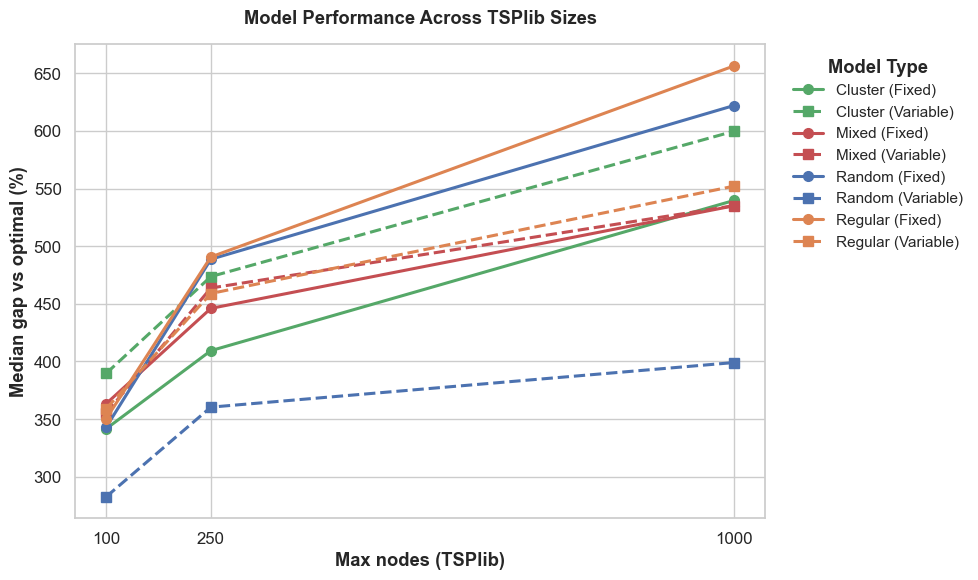

In [80]:
#plot tspLib data
#made with ai assistance
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("deep", 4)
dataset_types = ['random', 'regular', 'cluster', 'mixed']

for model_name, row in df.iterrows():
    # Strip .pt extension
    raw_label = os.path.splitext(model_name)[0]
    
    clean_label = raw_label.replace('datasets/', '').replace('_weights', '')
    base_name = clean_label.split('_')[0]
    
    # Assign color based on dataset type
    if base_name in dataset_types:
        color = colors[dataset_types.index(base_name)]
    else:
        color = 'black' # Fallback
        
    if clean_label.endswith('_n'):
        linestyle = '-'
        marker = 'o' # Circle marker
        label_display = f"{base_name.capitalize()} (Fixed)"
    else:
        linestyle = '--'
        marker = 's' # Square marker
        label_display = f"{base_name.capitalize()} (Variable)"

    ax.plot(df.columns, row.values, 
            marker=marker, markersize=7, 
            linestyle=linestyle, linewidth=2.2, 
            color=color, label=label_display)

# Formatting axes and title
ax.set_xlabel('Max nodes (TSPlib)', fontweight='bold')
ax.set_ylabel('Median gap vs optimal (%)', fontweight='bold')
ax.set_title('Model Performance Across TSPlib Sizes', fontweight='bold', pad=15)
ax.set_xticks(df.columns)

# Place a clean legend outside the plot
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, 
          frameon=False, title="Model Type", title_fontproperties={'weight': 'bold'})

fig.tight_layout()

# Save and show
plt.savefig('plots/tsplib_median_gaps.png', dpi=150, bbox_inches='tight')
print('Saved plot → plots/tsplib_median_gaps.png')
plt.show()

---
## 7. Generalization to larger graph instances

In [65]:
#same as tsplib but for synthetic
def evaluate_all_sizes_generated(device=config.device):
    weight_files = sorted(f for f in os.listdir(config.weight_dir) if f.endswith('.pt'))
    if not weight_files:
        print(f'No weight files found in {config.weight_dir}')
        return pd.DataFrame()

    size_results: dict[int, dict[str, float]] = {}

    for n in config.test_dataset_nodes:
        print(f'\nGenerated graphs  n_nodes={n}')

        dataset = build_dataset(
            graph_types  = ['random', 'regular', 'cluster'],
            n_graphs     = config.num_test_graphs,
            fixed_nodes  = n,
            base_seed    = config.seed,
        )
        loader = DataLoader(dataset, batch_size=16, shuffle=False)

        node_results: dict[str, float] = {}

        for filename in weight_files:
            path  = os.path.join(config.weight_dir, filename)
            model = TSPGNNModel(
                node_dim=2,
                edge_dim=1,
                hidden_dim=config.hidden_dim,
                n_layers=config.n_layers,
            ).to(device)
            model.load_state_dict(torch.load(path, map_location=device))
            model.eval()

            gaps = []
            with torch.no_grad():
                for batch in loader:
                    batch  = batch.to(device)
                    counts = torch.bincount(batch.batch)

                    h = model.encoder(batch)
                    tour_tensor, _, _ = model.decoder(h, batch.edge_index, batch.batch)

                    opt_tours_padded = _flat_to_padded_tours(
                        batch.tour, batch.batch, counts, device
                    )

                    opt_lens   = tour_length_batched(batch.x, opt_tours_padded, counts, batch.batch)
                    model_lens = tour_length_batched(batch.x, tour_tensor,      counts, batch.batch)

                    for ml, ol in zip(model_lens, opt_lens):
                        if ol > 0:
                            gaps.append((ml / ol - 1.0) * 100.0)

            median_gap = float(np.median(gaps)) if gaps else float('nan')
            node_results[filename] = median_gap
            print(f'  {filename:<40s}  median gap: {median_gap:.2f}%')

        size_results[n] = node_results

    df = pd.DataFrame(size_results)           # rows=models, cols=n
    df.index.name   = 'model'
    df.columns.name = 'n_nodes'
    df = df.sort_index()

    print('\nMedian gap (%) per model per size:')
    print(df.to_string(float_format='{:.2f}%'.format))
    return df


df_generated = evaluate_all_sizes_generated()


Generated graphs  n_nodes=50


random+regular+cluster:   0%|          | 0/30 [00:00<?, ?it/s]

  cluster_n_weights.pt                      median gap: 44.85%
  cluster_var_weights.pt                    median gap: 39.53%
  mixed_n_weights.pt                        median gap: 24.74%
  mixed_var_weights.pt                      median gap: 25.13%
  random_n_weights.pt                       median gap: 28.13%
  random_var_weights.pt                     median gap: 27.72%
  regular_n_weights.pt                      median gap: 47.43%
  regular_var_weights.pt                    median gap: 46.00%

Generated graphs  n_nodes=100


random+regular+cluster:   0%|          | 0/30 [00:00<?, ?it/s]

  cluster_n_weights.pt                      median gap: 88.09%
  cluster_var_weights.pt                    median gap: 53.55%
  mixed_n_weights.pt                        median gap: 71.09%
  mixed_var_weights.pt                      median gap: 43.72%
  random_n_weights.pt                       median gap: 64.58%
  random_var_weights.pt                     median gap: 52.64%
  regular_n_weights.pt                      median gap: 127.55%
  regular_var_weights.pt                    median gap: 71.54%

Generated graphs  n_nodes=250


random+regular+cluster:   0%|          | 0/30 [00:00<?, ?it/s]

  cluster_n_weights.pt                      median gap: 170.10%
  cluster_var_weights.pt                    median gap: 144.02%
  mixed_n_weights.pt                        median gap: 162.99%
  mixed_var_weights.pt                      median gap: 127.85%
  random_n_weights.pt                       median gap: 131.10%
  random_var_weights.pt                     median gap: 111.04%
  regular_n_weights.pt                      median gap: 287.60%
  regular_var_weights.pt                    median gap: 134.09%

Generated graphs  n_nodes=500


random+regular+cluster:   0%|          | 0/30 [00:00<?, ?it/s]

  cluster_n_weights.pt                      median gap: 268.30%
  cluster_var_weights.pt                    median gap: 232.79%
  mixed_n_weights.pt                        median gap: 232.96%
  mixed_var_weights.pt                      median gap: 207.62%
  random_n_weights.pt                       median gap: 184.31%
  random_var_weights.pt                     median gap: 151.81%
  regular_n_weights.pt                      median gap: 427.73%
  regular_var_weights.pt                    median gap: 206.96%

Median gap (%) per model per size:
n_nodes                   50      100     250     500
model                                                
cluster_n_weights.pt   44.85%  88.09% 170.10% 268.30%
cluster_var_weights.pt 39.53%  53.55% 144.02% 232.79%
mixed_n_weights.pt     24.74%  71.09% 162.99% 232.96%
mixed_var_weights.pt   25.13%  43.72% 127.85% 207.62%
random_n_weights.pt    28.13%  64.58% 131.10% 184.31%
random_var_weights.pt  27.72%  52.64% 111.04% 151.81%
regular_n_weights.pt

Saved plot → plots/mixed_median_gaps.png


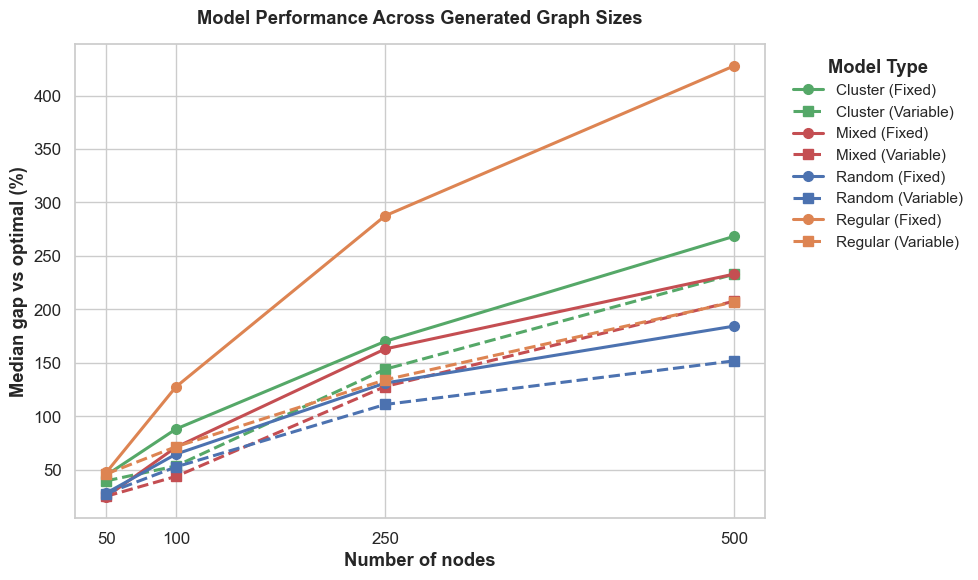

In [81]:
#plot mixed synthetic data
#made with ai assistance
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("deep", 4)
dataset_types = ['random', 'regular', 'cluster', 'mixed']

for model_name, row in df_generated.iterrows():
    raw_label = os.path.splitext(model_name)[0]
    clean_label = raw_label.replace('datasets/', '').replace('_weights', '')
    base_name = clean_label.split('_')[0]
    
    # Assign color based on dataset type
    if base_name in dataset_types:
        color = colors[dataset_types.index(base_name)]
    else:
        color = 'black' # Fallback
        
    if clean_label.endswith('_n'):
        linestyle = '-'
        marker = 'o' # Circle marker
        label_display = f"{base_name.capitalize()} (Fixed)"
    else:
        linestyle = '--'
        marker = 's' # Square marker
        label_display = f"{base_name.capitalize()} (Variable)"

    ax.plot(df_generated.columns, row.values, 
            marker=marker, markersize=7, 
            linestyle=linestyle, linewidth=2.2, 
            color=color, label=label_display)

# Formatting axes and title
ax.set_xlabel('Number of nodes', fontweight='bold')
ax.set_ylabel('Median gap vs optimal (%)', fontweight='bold')
ax.set_title('Model Performance Across Generated Graph Sizes', fontweight='bold', pad=15)
ax.set_xticks(df_generated.columns)

# Place a clean legend outside the plot
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, 
          frameon=False, title="Model Type", title_fontproperties={'weight': 'bold'})

fig.tight_layout()

plt.savefig('plots/mixed_median_gaps.png', dpi=150, bbox_inches='tight')
print('Saved plot → plots/mixed_median_gaps.png')
plt.show()